In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)


Using device: mps


In [2]:
def true_controlled_vdp_dynamics(x, u, mu=1.0, b=1.0):
    """
    Controlled Van der Pol dynamics:
        dx1/dt = x2
        dx2/dt = mu * (1 - x1^2) * x2 - x1 + b * u

    return:
        dx/dt = [dx1/dt, dx2/dt]
    """

    x1 = x[:, 0:1]
    x2 = x[:, 1:2]
    dx1dt = x2
    dx2dt = mu * (1 - x1**2) * x2 - x1 + b * u
    dxdt = torch.cat([dx1dt, dx2dt], dim=1)
    return dxdt



In [3]:
def rk4_step_true_controlled_vdp(x, u, dt, mu=1.0, b=1.0):
    """
    Perform one RK4 step for the controlled Van der Pol dynamics.
    """
    k1 = true_controlled_vdp_dynamics(x, u, mu, b)
    k2 = true_controlled_vdp_dynamics(x + 0.5 * dt * k1, u, mu, b)
    k3 = true_controlled_vdp_dynamics(x + 0.5 * dt * k2, u, mu, b)
    k4 = true_controlled_vdp_dynamics(x + dt * k3, u, mu, b)
    x_next = x + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
    return x_next



In [4]:
class ControlledVanDerPolDataset(Dataset):
    def __init__(
        self,
        n_traj=200,
        n_steps=200,
        T=15.0,
        mu=1.0,
        b=1.0,
        x0_min=-3.0,
        x0_max=3.0,
        seed=42
    ):
        """
        Dataset for Controlled Van der Pol:

            dx1/dt = x2
            dx2/dt = mu*(1-x1^2)*x2 - x1 + b*u

        Each sample:
            x0: [2]
            u:  [n_steps-1, 1]
            x:  [n_steps, 2]
        """

        self.n_traj = n_traj
        self.n_steps = n_steps
        self.T = T
        self.mu = mu
        self.b = b

        generator = torch.Generator().manual_seed(seed)

        self.t = torch.linspace(0.0, T, n_steps)

        self.x0 = torch.empty(n_traj, 2).uniform_(
            x0_min, x0_max, generator=generator
        )

        self.u = self._generate_smooth_inputs(generator)
        self.x = self._simulate_trajectories()

    def _generate_smooth_inputs(self, generator):
        """
        Generate smooth input u(t) by summing sine waves.
        u shape: [n_traj, n_steps-1, 1]
        """

        t_u = self.t[:-1].view(1, 1, self.n_steps - 1)

        freqs = torch.tensor([0.3, 0.7, 1.2]).view(1, 3, 1)

        amps = torch.empty(self.n_traj, 3, 1).uniform_(
            -1.0, 1.0, generator=generator
        )

        phases = torch.empty(self.n_traj, 3, 1).uniform_(
            0.0, 2.0 * torch.pi, generator=generator
        )

        u_components = amps * torch.sin(freqs * t_u + phases)

        u = u_components.sum(dim=1) / 3.0
        
        u = torch.clamp(u, -1.0, 1.0)  # Ensure u is in [-1, 1]

        return u.unsqueeze(-1)

    def _simulate_trajectories(self):
        """
        Use RK4 true to generate state trajectories.
        """

        xs = [self.x0]
        x = self.x0

        for k in range(self.n_steps - 1):
            dt = self.t[k + 1] - self.t[k]
            u_k = self.u[:, k, :]

            x = rk4_step_true_controlled_vdp(
                x=x,
                u=u_k,
                dt=dt,
                mu=self.mu,
                b=self.b
            )

            xs.append(x)

        return torch.stack(xs, dim=1)

    def __len__(self):
        return self.n_traj

    def __getitem__(self, idx):
        return {
            "x0": self.x0[idx],
            "u": self.u[idx],
            "x": self.x[idx]
        }
    
    

In [5]:
dataset = ControlledVanDerPolDataset(
    n_traj=200,
    n_steps=200,
    T=15.0,
    mu=1.0,
    b=1.0
)

sample = dataset[0]

print("Number of trajectories:", len(dataset))
print("t shape:", dataset.t.shape)
print("x0 shape:", sample["x0"].shape)
print("u shape:", sample["u"].shape)
print("x shape:", sample["x"].shape)

Number of trajectories: 200
t shape: torch.Size([200])
x0 shape: torch.Size([2])
u shape: torch.Size([199, 1])
x shape: torch.Size([200, 2])


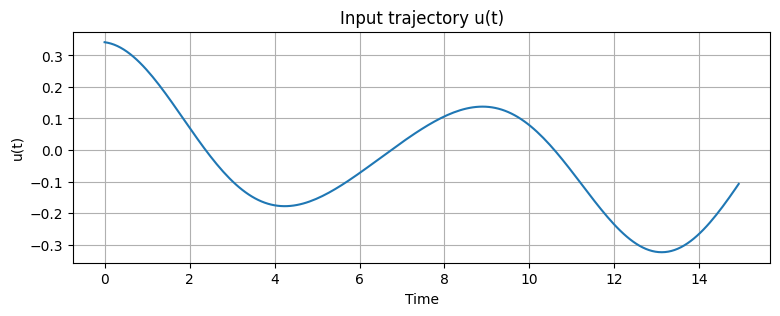

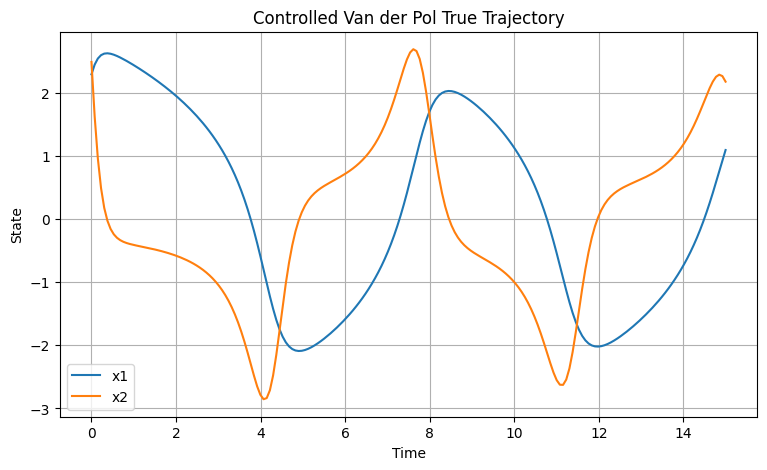

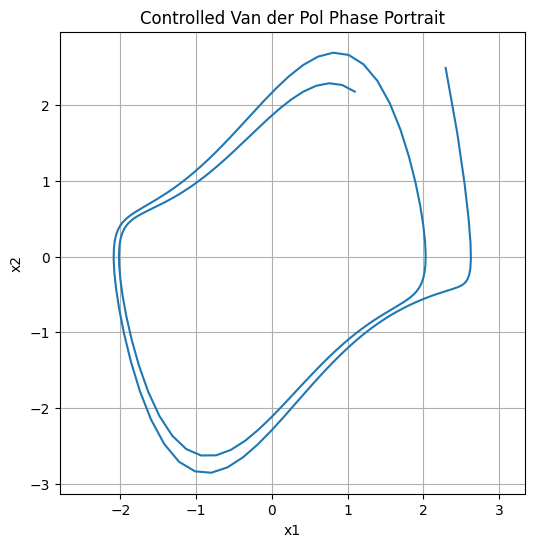

In [6]:
idx = 0
sample = dataset[idx]
t = dataset.t

plt.figure(figsize=(9, 3))
plt.plot(t[:-1].numpy(), sample["u"][:, 0].numpy())
plt.xlabel("Time")
plt.ylabel("u(t)")
plt.title("Input trajectory u(t)")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(t.numpy(), sample["x"][:, 0].numpy(), label="x1")
plt.plot(t.numpy(), sample["x"][:, 1].numpy(), label="x2")
plt.xlabel("Time")
plt.ylabel("State")
plt.title("Controlled Van der Pol True Trajectory")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(sample["x"][:, 0].numpy(), sample["x"][:, 1].numpy())
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Controlled Van der Pol Phase Portrait")
plt.grid(True)
plt.axis("equal")
plt.show()

In [7]:
class ControlledVanDerPolNODEFunc(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3, 64),   # x1, x2, u
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2)    # dx1dt, dx2dt
        )

    def forward(self, x, u):
        """
        x shape: [batch_size, 2]
        u shape: [batch_size, 1]

        return:
            dxdt shape: [batch_size, 2]
        """

        xu = torch.cat([x, u], dim=1)
        dxdt = self.net(xu)
        return dxdt

In [8]:
def rk4_solve_controlled_node(func, x0, u, t):
    """
    Use NODE to generate trajectory predictions.

    func: NODE model learn dx/dt = f_theta(x,u)
    x0: [batch_size, 2]
    u:  [batch_size, n_steps-1, 1]
    t:  [n_steps]

    return:
        xs: [batch_size, n_steps, 2]
    """

    xs = [x0]
    x = x0

    for k in range(len(t) - 1):
        dt = t[k + 1] - t[k]
        u_k = u[:, k, :]

        k1 = func(x, u_k)
        k2 = func(x + 0.5 * dt * k1, u_k)
        k3 = func(x + 0.5 * dt * k2, u_k)
        k4 = func(x + dt * k3, u_k)

        x = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

        xs.append(x)

    return torch.stack(xs, dim=1)



In [9]:
from torch.utils.data import random_split, DataLoader

dataset = ControlledVanDerPolDataset(
    n_traj=200,
    n_steps=200,
    T=15.0,
    mu=1.0,
    b=1.0
)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


Train samples: 160
Test samples: 40


In [10]:
t = dataset.t.to(device)

func = ControlledVanDerPolNODEFunc().to(device)

optimizer = torch.optim.Adam(func.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

n_epochs = 1000

best_loss = float("inf")

for epoch in range(n_epochs):
    func.train()
    total_loss = 0.0

    for batch in train_loader:
        x0_batch = batch["x0"].to(device)
        u_batch = batch["u"].to(device)
        true_x = batch["x"].to(device)

        optimizer.zero_grad()

        pred_x = rk4_solve_controlled_node(
            func=func,
            x0=x0_batch,
            u=u_batch,
            t=t
        )

        loss = loss_fn(pred_x, true_x)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    if avg_loss < best_loss:
        best_loss = avg_loss

        checkpoint = {
            "model_state_dict": func.state_dict(),
            "model_name": "ControlledVanDerPolNODEFunc",
            "mu": dataset.mu,
            "b": dataset.b,
            "T": dataset.T,
            "n_steps": dataset.n_steps,
            "n_traj": dataset.n_traj,
            "dt": (dataset.t[1] - dataset.t[0]).item(),
            "epoch": epoch,
            "best_loss": best_loss,
            "batch_size": train_loader.batch_size,
            "learning_rate": 0.001,
        }

        torch.save(checkpoint, "controlled_vdp_node_best.pt")

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Loss = {avg_loss:.8f} | Best = {best_loss:.8f}")

Epoch    0 | Loss = 4.76078892 | Best = 4.76078892
Epoch  200 | Loss = 0.38405176 | Best = 0.37088153
Epoch  400 | Loss = 0.13426821 | Best = 0.11953054
Epoch  600 | Loss = 0.08474304 | Best = 0.05692563
Epoch  800 | Loss = 0.04371773 | Best = 0.03356757


In [11]:
def predict_on_loader(func, dataloader, t, device):
    func.eval()

    all_pred = []
    all_true = []

    with torch.no_grad():
        for batch in dataloader:
            x0_batch = batch["x0"].to(device)
            u_batch = batch["u"].to(device)
            true_x = batch["x"].to(device)

            pred_x = rk4_solve_controlled_node(
                func=func,
                x0=x0_batch,
                u=u_batch,
                t=t
            )

            all_pred.append(pred_x.cpu())
            all_true.append(true_x.cpu())

    all_pred = torch.cat(all_pred, dim=0)
    all_true = torch.cat(all_true, dim=0)

    return all_pred, all_true

In [12]:
pred_test, true_test = predict_on_loader(
    func=func,
    dataloader=test_loader,
    t=t,
    device=device
)

print("pred_test shape:", pred_test.shape)
print("true_test shape:", true_test.shape)

pred_test shape: torch.Size([40, 200, 2])
true_test shape: torch.Size([40, 200, 2])


In [13]:
def compute_metrics(pred, true, eps=1e-8):
    """
    pred, true shape: [N, T, D]
    N = number of trajectories
    T = number of time steps
    D = number of state dimensions
    """

    error = pred - true

    mae = torch.mean(torch.abs(error), dim=(0, 1))

    rmse = torch.sqrt(torch.mean(error ** 2, dim=(0, 1)))

    data_range = torch.max(true, dim=0).values.max(dim=0).values - \
                 torch.min(true, dim=0).values.min(dim=0).values

    nrmse = rmse / (data_range + eps)

    ss_res = torch.sum((true - pred) ** 2, dim=(0, 1))
    true_mean = torch.mean(true, dim=(0, 1))
    ss_tot = torch.sum((true - true_mean) ** 2, dim=(0, 1))

    r2 = 1.0 - ss_res / (ss_tot + eps)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "NRMSE": nrmse,
        "R2": r2
    }

In [14]:
metrics = compute_metrics(pred_test, true_test)

for name, value in metrics.items():
    print(name, value.numpy())

MAE [0.12851137 0.1652677 ]
RMSE [0.18373534 0.23898317]
NRMSE [0.03177379 0.03313829]
R2 [0.98455846 0.971225  ]


In [15]:
state_names = ["x1", "x2"]

print(f"{'State':<8} {'MAE':>12} {'RMSE':>12} {'NRMSE':>12} {'R2':>12}")
print("-" * 60)

for i, name in enumerate(state_names):
    print(
        f"{name:<8} "
        f"{metrics['MAE'][i].item():>12.6f} "
        f"{metrics['RMSE'][i].item():>12.6f} "
        f"{metrics['NRMSE'][i].item():>12.6f} "
        f"{metrics['R2'][i].item():>12.6f}"
    )

State             MAE         RMSE        NRMSE           R2
------------------------------------------------------------
x1           0.128511     0.183735     0.031774     0.984558
x2           0.165268     0.238983     0.033138     0.971225


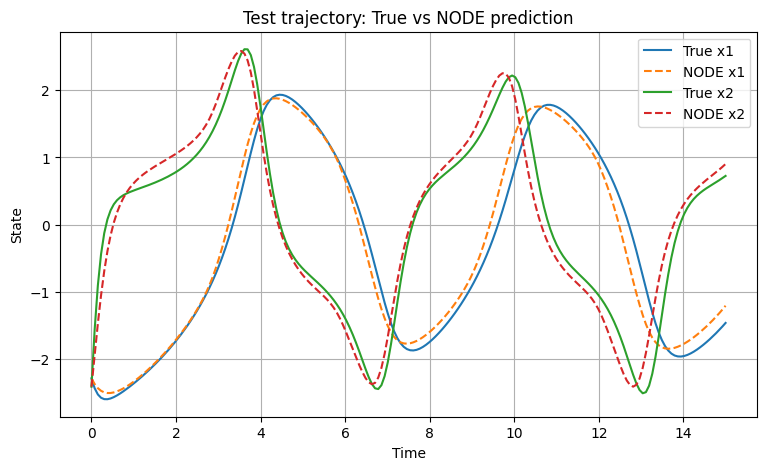

In [16]:
idx = 0

plt.figure(figsize=(9, 5))
plt.plot(dataset.t.numpy(), true_test[idx, :, 0].numpy(), label="True x1")
plt.plot(dataset.t.numpy(), pred_test[idx, :, 0].numpy(), "--", label="NODE x1")
plt.plot(dataset.t.numpy(), true_test[idx, :, 1].numpy(), label="True x2")
plt.plot(dataset.t.numpy(), pred_test[idx, :, 1].numpy(), "--", label="NODE x2")
plt.xlabel("Time")
plt.ylabel("State")
plt.title("Test trajectory: True vs NODE prediction")
plt.legend()
plt.grid(True)
plt.show()

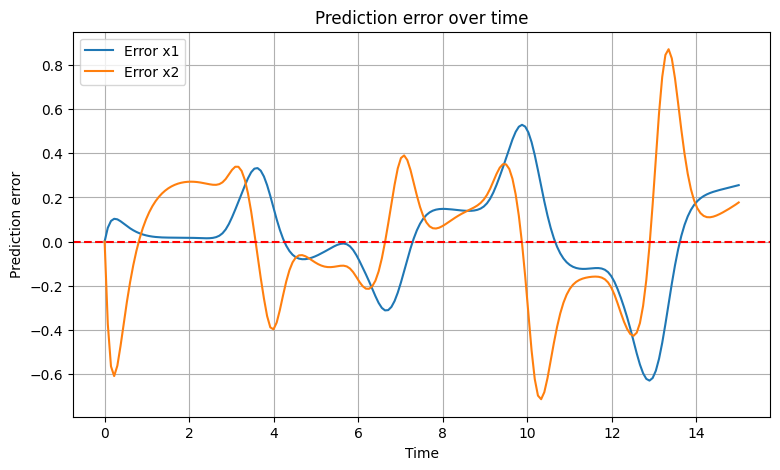

In [17]:
error = pred_test[idx] - true_test[idx]

plt.figure(figsize=(9, 5))
plt.plot(dataset.t.numpy(), error[:, 0].numpy(), label="Error x1")
plt.plot(dataset.t.numpy(), error[:, 1].numpy(), label="Error x2")
plt.axhline(0.0, linestyle="--", color="red")
plt.xlabel("Time")
plt.ylabel("Prediction error")
plt.title("Prediction error over time")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
def compute_horizon_metrics(pred, true, t, horizons):
    """
    horizons: list of time steps that used to be evaluated [2, 5, 10, 15]
    """

    results = {}

    for H in horizons:
        # Find the index in t that is closest to H
        idx_H = torch.argmin(torch.abs(t - H)).item()

        pred_H = pred[:, :idx_H + 1, :]
        true_H = true[:, :idx_H + 1, :]

        results[H] = compute_metrics(pred_H, true_H)

    return results

In [19]:
horizons = [2.0, 5.0, 10.0, 15.0]

horizon_results = compute_horizon_metrics(
    pred=pred_test,
    true=true_test,
    t=dataset.t,
    horizons=horizons
)

In [20]:
for H, m in horizon_results.items():
    print(f"\nHorizon: {H} seconds")
    print(f"{'State':<8} {'MAE':>12} {'RMSE':>12} {'NRMSE':>12} {'R2':>12}")
    print("-" * 60)

    for i, name in enumerate(state_names):
        print(
            f"{name:<8} "
            f"{m['MAE'][i].item():>12.6f} "
            f"{m['RMSE'][i].item():>12.6f} "
            f"{m['NRMSE'][i].item():>12.6f} "
            f"{m['R2'][i].item():>12.6f}"
        )


Horizon: 2.0 seconds
State             MAE         RMSE        NRMSE           R2
------------------------------------------------------------
x1           0.075956     0.113676     0.019658     0.995373
x2           0.189607     0.267481     0.038487     0.955398

Horizon: 5.0 seconds
State             MAE         RMSE        NRMSE           R2
------------------------------------------------------------
x1           0.091953     0.142146     0.024582     0.991615
x2           0.165576     0.238518     0.033074     0.970372

Horizon: 10.0 seconds
State             MAE         RMSE        NRMSE           R2
------------------------------------------------------------
x1           0.107481     0.157115     0.027170     0.988794
x2           0.153742     0.218786     0.030338     0.976206

Horizon: 15.0 seconds
State             MAE         RMSE        NRMSE           R2
------------------------------------------------------------
x1           0.128511     0.183735     0.031774     0.98

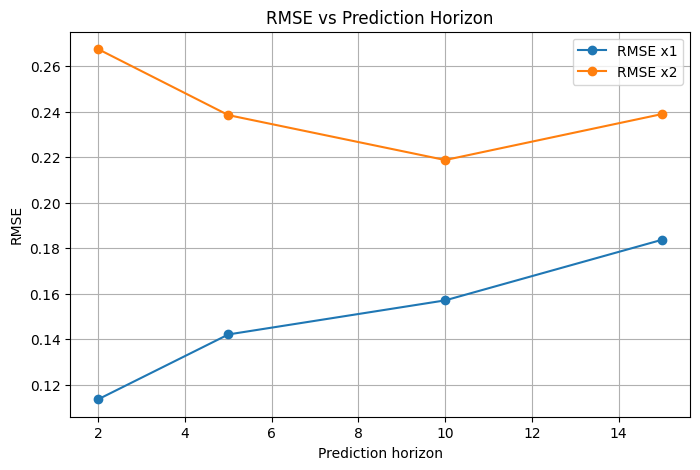

In [21]:
horizon_values = []
rmse_x1_values = []
rmse_x2_values = []

for H, m in horizon_results.items():
    horizon_values.append(H)
    rmse_x1_values.append(m["RMSE"][0].item())
    rmse_x2_values.append(m["RMSE"][1].item())

plt.figure(figsize=(8, 5))
plt.plot(horizon_values, rmse_x1_values, marker="o", label="RMSE x1")
plt.plot(horizon_values, rmse_x2_values, marker="o", label="RMSE x2")
plt.xlabel("Prediction horizon")
plt.ylabel("RMSE")
plt.title("RMSE vs Prediction Horizon")
plt.legend()
plt.grid(True)
plt.show()